In [1]:
import pandas as pd 
import optuna
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [5]:
import pandas as pd
df = pd.read_csv('../data/data_for_model.csv', index_col='Date', parse_dates=True)

In [6]:
df['Month'] = df.index.month

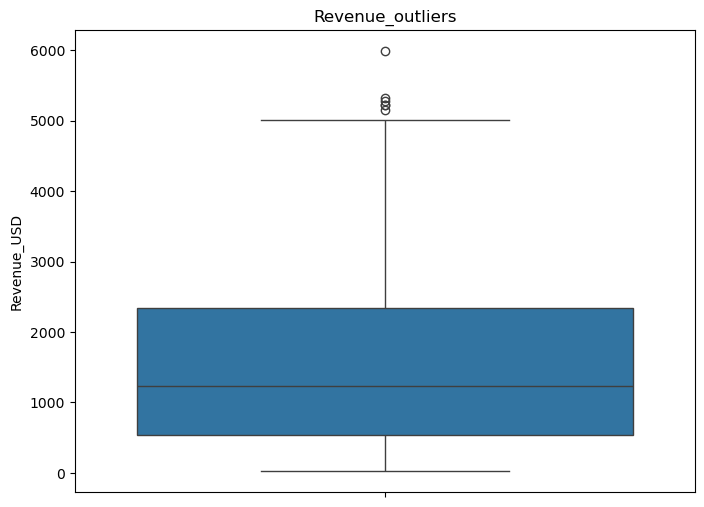

In [7]:
plt.figure(figsize=(8,6))
sns.boxplot(data= df['Revenue_USD'])
plt.title('Revenue_outliers')
plt.show()

In [8]:
Q1 = df['Revenue_USD'].quantile(0.25)
Q3 = df['Revenue_USD'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Revenue_USD'] >= lower_bound) & (df['Revenue_USD'] <= upper_bound)]

In [9]:
cols_to_drop = ['Revenue_USD', 'Units_Sold', 'Sale_ID']
target = 'Revenue_USD'
X = df.drop(columns= cols_to_drop)
y = df[target]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size = 0.2)

In [11]:
num_col = X.select_dtypes(include='number').columns
cat_col = X.select_dtypes(include='object').columns

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_21188\4292161370.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = X.select_dtypes(include='object').columns


In [12]:
num_proccesor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [13]:
cat_proccesor = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('OneHotEncoder', OneHotEncoder())
])

In [14]:
preproccesor = ColumnTransformer([
    ('num_procesor', num_proccesor, num_col),
    ('cat_procesor', cat_proccesor, cat_col)
])

In [15]:
model = RandomForestRegressor(random_state=42)

In [16]:
pipeline = Pipeline([
    ('procesowanie', preproccesor),
    ('model', model)
])

In [17]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [18]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Błąd średni (MAE): {mae:.2f} USD")
print(f"Błąd pierwiastkowy (RMSE): {rmse:.2f} USD")
print(f"Skuteczność (R2): {r2:.2f}")

Błąd średni (MAE): 677.33 USD
Błąd pierwiastkowy (RMSE): 944.08 USD
Skuteczność (R2): 0.33


In [19]:
def objective(trial):
    
    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 20, 120),
        'model__max_depth': trial.suggest_int('model__max_depth', 5, 20),
        'model__min_samples_split': trial.suggest_int('model__min_samples_split', 2, 10),
        'model__min_samples_leaf': trial.suggest_int('model__min_samples_leaf', 1, 10),
    }

    pipeline.set_params(**params)

    
    pipeline.fit(X_train, y_train)

    
    y_pred = pipeline.predict(X_test)

    
    mae = mean_absolute_error(y_test, y_pred)

    return mae

    

In [20]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20, show_progress_bar=True)


[I 2026-04-10 21:06:15,717] A new study created in memory with name: no-name-da398f67-7940-4432-863f-61fbed25f453


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-10 21:06:15,794] Trial 0 finished with value: 700.6998372615038 and parameters: {'model__n_estimators': 23, 'model__max_depth': 19, 'model__min_samples_split': 4, 'model__min_samples_leaf': 2}. Best is trial 0 with value: 700.6998372615038.
[I 2026-04-10 21:06:15,855] Trial 1 finished with value: 686.7731633036436 and parameters: {'model__n_estimators': 50, 'model__max_depth': 11, 'model__min_samples_split': 5, 'model__min_samples_leaf': 10}. Best is trial 1 with value: 686.7731633036436.
[I 2026-04-10 21:06:15,983] Trial 2 finished with value: 692.7593272264519 and parameters: {'model__n_estimators': 58, 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2}. Best is trial 1 with value: 686.7731633036436.
[I 2026-04-10 21:06:16,124] Trial 3 finished with value: 680.8825306889371 and parameters: {'model__n_estimators': 100, 'model__max_depth': 17, 'model__min_samples_split': 2, 'model__min_samples_leaf': 8}. Best is trial 3 with value: 680.88253

In [21]:
print("Best trial:", study.best_trial)
print("Best hyperparameters:", study.best_params)

Best trial: FrozenTrial(number=14, state=<TrialState.COMPLETE: 1>, values=[666.6818855491312], datetime_start=datetime.datetime(2026, 4, 10, 21, 6, 17, 372576), datetime_complete=datetime.datetime(2026, 4, 10, 21, 6, 17, 491867), params={'model__n_estimators': 68, 'model__max_depth': 18, 'model__min_samples_split': 8, 'model__min_samples_leaf': 4}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'model__n_estimators': IntDistribution(high=120, log=False, low=20, step=1), 'model__max_depth': IntDistribution(high=20, log=False, low=5, step=1), 'model__min_samples_split': IntDistribution(high=10, log=False, low=2, step=1), 'model__min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1)}, trial_id=14, value=None)
Best hyperparameters: {'model__n_estimators': 68, 'model__max_depth': 18, 'model__min_samples_split': 8, 'model__min_samples_leaf': 4}


In [22]:
pipeline.set_params(**study.best_params)

# Ostateczny trening na najlepszych ustawieniach
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [23]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Błąd średni (MAE): {mae:.2f} USD")
print(f"Błąd pierwiastkowy (RMSE): {rmse:.2f} USD")
print(f"Skuteczność (R2): {r2:.2f}")

Błąd średni (MAE): 666.68 USD
Błąd pierwiastkowy (RMSE): 917.91 USD
Skuteczność (R2): 0.37


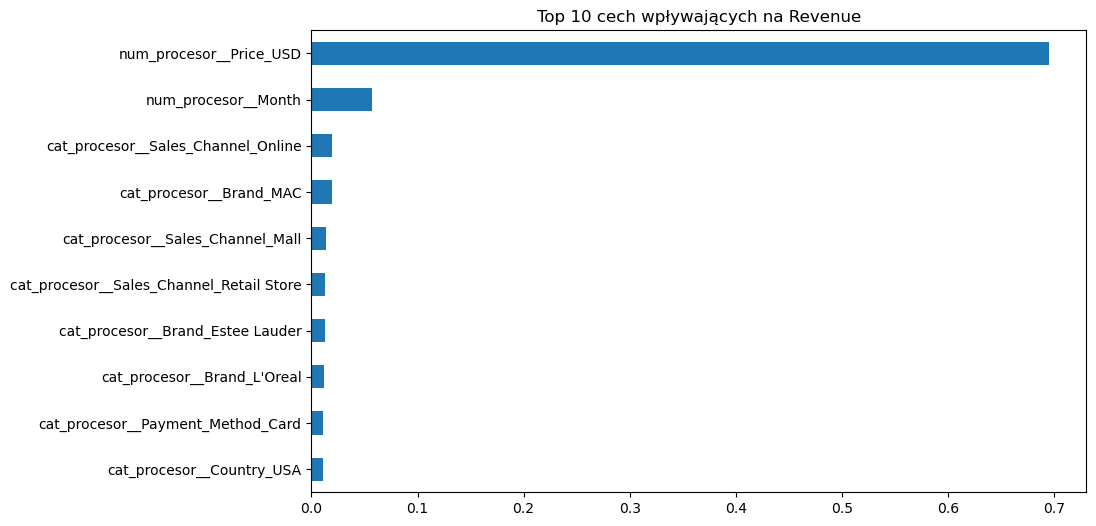

In [24]:
importances = pipeline.named_steps['model'].feature_importances_
features = pipeline.named_steps['procesowanie'].get_feature_names_out()

# Tworzymy  wykres  przedtawiający 10 najważniejszych cech dla modelu
plt.figure(figsize=(10, 6))
pd.Series(importances, index=features).sort_values().tail(10).plot(kind='barh')
plt.title("Top 10 cech wpływających na Revenue")
plt.savefig('../images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()